# 프로젝트 : mini BERT 만들기

- 프로젝트의 과제: vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 1M 정도가 되는 아주 작은 mini BERT 모델을 만들어 10 Epoch까지 학습시킨 모델을 만들어 보는 것입니다.
가장 대표적인 pretrained ㅣlanguage model인 BERT의 pretrain 전과정을 진행해 보면서 BERT의 핵심원리를 깊이 이해해 본다.

# 1. Data download : 기 다운받은 kowiki.txt 사용

- [kowiki.txt.zip](https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip)


```
$ mkdir -p ~/work/bert_pretrain/data
$ mkdir -p ~/work/bert_pretrain/models
$ wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
$ mv kowiki.txt.zip ~/work/bert_pretrain/data
$ cd ~/work/bert_pretrain/data && unzip kowiki.txt.zip
```

혹시 이번 실습에서 필요한 아래 라이브러리가 없다면 미리 설치해 주세요.
```
$ pip install sentencepiece
$ pip install tqdm
$ conda install -c conda-forge ipywidgets
$ jupyter nbextension enable --py widgetsnbextension
```

```
#로컬에서 진행하실 경우 다음과 같이 경로설정을 합니다  
#!mkdir data
#!mkdir models
```

```
#LMS에는 데이터가 준비되어 있습니다  
#!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
```

```
#LMS에는 데이터가 준비되어 있습니다
#!mv kowiki.txt.zip /content/data
```

```
#LMS에는 데이터가 압축이 풀린 채로 준비되어 있습니다.
#%cd /content/data
#!unzip kowiki.txt.zip
```

```
#다음 라이브러리를 설치해주세요
!pip install sentencepiece
!pip install tqdm
!conda install -y -c conda-forge ipywidgets
!jupyter nbextension enable --py widgetsnbextension
!pip install torchsummary
```


# 2. Tokenizer 준비
- SentencePiece 모델을 이용해 BERT의 MLM 학습용 데이터를 만드세요. (BERT pretrain 과정)
- 이를 위해 한글 나무 위키 코퍼스로부터 8000의 vocab_size를 갖는 sentencepiece 모델을 만들어 보세요. BERT에 사용되는 주요 특수문자가 vocab에 포함되어야 합니다. (시간이 부족하다면 클라우드에 저장된 sentencepiece 모델을 사용하세요.)

In [1]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchsummary import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)

# torch version
print(torch.__version__)

2.7.1+cu118


## ko_8000.model, ko_8000.vocab 생성
(위치: ~/work/bert_pretrain/models)
<details>
<summary>sentencepiece 사용해서 vocal 생성 방법</summary>
    
- 한글 나무위키 코퍼스로부터 8000의 vocab_size를 갖는 sentencepiece 모델 생성
- BERT에 사용되는 [MASK], [SEP], [CLS] 등의 주요 특수문자가 vocab에 포함되어야 함에 주의해 주세요.

(선택) 직접 model 과 vocab 을 만들기 : cloud shell을 열어 아래 코드를 한줄씩 실행해주세요.
```
$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = os.getenv('HOME')+'/work/bert_pretrain/data/kowiki.txt'
>>> prefix = os.getenv('HOME')+'/work/bert_pretrain/models/ko_8000'
>>> vocab_size = 8000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
```
</details>

In [2]:
import sentencepiece as spm
import os
corpus_file = os.getenv('HOME')+'/work/bert_pretrain/data/kowiki.txt'
prefix = os.getenv('HOME')+'/work/bert_pretrain/models/ko_8000'
vocab_size = 8000
spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} \
                            --vocab_size={vocab_size + 7} --model_type=bpe \
                            --max_sentence_length=999999 --pad_id=0 \
                            --pad_piece=[PAD] --unk_id=1 \
                            --unk_piece=[UNK] --bos_id=2 \
                            --bos_piece=[BOS] --eos_id=3 \
                            --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]"
)


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=/home/jovyan/work/bert_pretrain/data/kowiki.txt --model_prefix=/home/jovyan/work/bert_pretrain/models/ko_8000                             --vocab_size=8007 --model_type=bpe                             --max_sentence_length=999999 --pad_id=0                             --pad_piece=[PAD] --unk_id=1                             --unk_piece=[UNK] --bos_id=2                             --bos_piece=[BOS] --eos_id=3                             --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /home/jovyan/work/bert_pretrain/data/kowiki.txt
  input_format: 
  model_prefix: /home/jovyan/work/bert_pretrain/models/ko_8000
  model_type: BPE
  vocab_size: 8007
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence

In [3]:
# data_dir = '~/work/bert_pretrain/models'  # python 내에서 ~ 불가
data_dir = os.path.expanduser('~/work/bert_pretrain/models')
vocab_path = os.path.join(data_dir, 'ko_8000.model')

# vocab loading
vocab = spm.SentencePieceProcessor()
vocab.load(vocab_path)

True

In [4]:
# 토크나이저 생성 확인

#Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
count = 0
for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
                
for i in range(20): # 20개만 출력
    print(vocab_list[i], end=' ')

▁이 ▁1 으로 에서 ▁있 ▁그 ▁대 ▁2 ▁사 었다 ▁수 ▁지 ▁가 하였 ▁기 ▁전 ▁시 이다 ▁19 ▁있다 

In [5]:
# tokens_org : test용 데이터
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성

string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


# 3. 데이터 전처리
## (1) MASK 생성
- BERT의 Masked Language Model(MLM) : 마스킹 된 단어 푸는 문제
- BERT의 MLM에 필요한 빈칸(mask)을 학습 데이터 전체 토큰의 15% 정도로 만들어 주세요. 그 중 80%는 [MASK] 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용하세요.

### 🔶 create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드

In [6]:
# 1. 학습 데이터 전체 토큰의 15% 정도 mask 대상으로 설정
# 2. 그 중 80%는 [MASK] 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용

def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask 하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    # random mask를 위해서 순서를 섞음 (shuffle)
    random.shuffle(cand_idx)

    # mask
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:  # 1. 학습 데이터 전체 토큰의 15% 정도 mask 대상으로 설정
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:    # 2. 그 중 80%는 [MASK] 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출 (sorted 사용)
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

#### create_pretrain_mask() 수행 결과 확인 : test data(tokens_org) 이용

In [7]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)

tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '[MASK]', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁마드리', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘', '러', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '

## (2) NSP pair 생성
- BERT의 pretrain task인 NSP(Next Sentence Prediction)는 두 문장이 연속하는지 확인하는 것입니다. 이를 위해 2개의 문장을 짝지어 50%의 확률로 TRUE와 FALSE를 지정해 주세요.

- 두 문장 사이에 segment 처리를 해주세요. 첫 번째 문장의 segment는 0, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 [SEP] 등을 넣어주세요.

- 아래와 같이 문장 A의 다음 문장이 B일 경우는 TRUE, 아니면 FALSE로 예측하게 합니다.

```
[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 그 사람이 바다의 뚜껑 닫지 않고 돌아가[SEP] → TRUE(IsNext)

[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 한강에서 자전거 타며 아이스아메리카노를 마시고 싶다[SEP] → FALSE(NotNext)
```
- BERT의 pretrain은 MLM과 NSP, 두 가지 task가 동시에 수행
    - MLM (Masked Language Modeling) : 문장에서 랜덤으로 가린 단어를 맞추기
    - NSP (Next Sentence Prediction) : 두 문장이 이어지는지 아닌지 맞추기
      

#### 예시 문장

In [8]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [9]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'],
 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아'],
 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

In [10]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

## 🔶 create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드

In [11]:
# 두 문장 생성
# -> 50%의 확률로 true/false 케이스를 생성 (is_next = 0 : 순서 변경, 즉 잘못된 순서)
# -> 두 문장 합의 최대 길이를 유지하도록 trim 적용 
# -> tokens & segment 생성
# -> mask

def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0
    for i in range(len(doc)):

        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            if random.random() < 0.5:
                is_next = 0
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * mask_prob), vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0
    return instances

#### create_pretrain_instances() 수행 결과 확인 : test data 이용

In [12]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEB], tokens_b, [SEP]
max_seq = n_test_seq - 3

instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[SEP]', '▁그', '날', '은', '▁', '왠', '지', '[MASK]', '[MASK]', '[MASK]', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '[MASK]', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁흘', '러', '▁', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [19, 20, 21, 31, 55, 56, 57, 58, 59], 'mask_label': ['▁손', '님', '이', '▁번', '▁기', '쁨', '의', '▁눈', '물이']}
{'tokens': ['[CLS]', '[MASK]', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '[MASK]', '[MASK]', '▁살', '▁수', '▁있어', '[MASK]'

## (3) 데이터셋 완성
- BERT pretrain 데이터셋을 생성해, json 포맷으로 저장하세요. 데이터셋의 사이즈가 크므로np.memmap을 사용해 메모리 사용량을 최소화해 보세요.

In [13]:
# corpus_file = 'data/kowiki.txt'

# data_dir = '~/work/bert_pretrain/models'  # ~가 Python에서 자동으로 홈 디렉토리로 확장 불가
data_dir = os.path.expanduser('~/work/bert_pretrain/data')
corpus_file = os.path.join(data_dir, 'kowiki.txt')


# line count 확인
total = 0
with open(corpus_file, 'r') as in_f:
    for line in in_f:
        total += 1

total

858829

### 🔶 make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드
전체 전처리 과정을 거쳐 최종적으로 만들어지는 BERT pretrain 데이터셋 생성 메소드

In [14]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):        # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            vocab_list.append(vocab.id_to_piece(id))

    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1

    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt):
                line = line.strip()
                if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                    if 0 < len(doc):
                        save_pretrain_instances(out_f, doc)
                        doc = []
                else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
                save_pretrain_instances(out_f, doc)
                doc = []

#### 전체 코퍼스에 대해 make_pretrain_data() 실행
최종적으로 생성된 데이터셋은 json 포맷으로 저장

In [15]:
# pretrain_json_path = 'work/bert_pre_train.json'

data_dir = os.path.expanduser('~/work/bert_pretrain')
pretrain_json_path = os.path.join(data_dir, 'bert_pre_train.json')

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)


  0%|          | 0/858829 [00:00<?, ?it/s]

In [16]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

237180

In [17]:
# json 한 줄 원본 확인

import json

with open(pretrain_json_path, 'r', encoding='utf-8') as f:
    line = f.readline()
    print(line)              # 원본 문자열
    sample = json.loads(line)
    print(sample.keys())     # 어떤 키들이 있는지


{"tokens": ["[CLS]", "▁지", "미", "▁카", "터", "[SEP]", "▁제임스", "▁얼", "▁\"", "지", "미", "\"", "▁카", "터", "▁주", "니", "어", "(,", "[MASK]", "[MASK]", "[MASK]", "▁10", "월", "▁1", "일", "▁~", "▁)", "는", "[MASK]", "[MASK]", "▁출신", "▁미국", "[MASK]", "[MASK]", "[MASK]", "[MASK]", "▁(19", "7", "7", "년", "▁~", "▁1981", "년", ")", "이다", ".", "▁지", "미", "▁카", "터", "는", "▁조지", "아", "주", "▁섬", "터", "[MASK]", "[MASK]", "[MASK]", "▁플", "레", "인", "스", "▁마을", "에서", "▁태어났다", ".", "▁조지", "아", "▁공", "과", "대학교", "를", "▁졸업", "하였다", ".", "▁그", "▁후", "▁해", "군에", "▁들어가", "▁전", "함", "·", "원", "자", "력", "·", "잠", "수", "함", "의", "▁승", "무", "원으로", "▁일", "하였다", ".", "▁195", "3", "년", "[MASK]", "▁해군", "[MASK]", "[MASK]", "▁예", "편", "하였고", "▁이후", "▁땅", "콩", "·", "면", "화", "▁등을", "▁가", "꿔", "▁많은", "▁돈", "을", "[MASK]", "[MASK]", "[MASK]", "▁그의", "▁별", "명이", "▁\"", "[SEP]"], "segment": [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [20]:
# json 데이터 확인

import json

with open(pretrain_json_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        sample = json.loads(line.strip())
        
        tokens = sample.get('tokens', [])
        segments = sample.get('segments', sample.get('segment', []))
        mlm_positions = sample.get('masked_lm_positions', sample.get('mask_idx', []))
        mlm_labels = sample.get('masked_lm_labels', sample.get('mask_label', []))
        is_next = sample.get('is_next', None)

        print(f"\n=== Sample {i+1} ===")
        print(f"tokens: {tokens[:40]}")
        print(f"  (총 {len(tokens)}개)")
        
        print(f"segments: {segments}")
        print(f"  (총 {len(segments)}개, 0/1 비율: {segments.count(0)}/{segments.count(1) if len(segments) > 0 else 0})")
        
        print(f"masked_lm_positions: {mlm_positions}")
        print(f"  ({len(mlm_positions)}개 위치)")
        
        print(f"masked_lm_labels: {mlm_labels}")
        print(f"  ({len(mlm_labels)}개 라벨)")
        
        print(f"is_next: {is_next}")
        print("-" * 60)


=== Sample 1 ===
tokens: ['[CLS]', '▁지', '미', '▁카', '터', '[SEP]', '▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '[MASK]', '[MASK]', '[MASK]', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '[MASK]', '[MASK]', '▁출신', '▁미국', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁(19', '7', '7', '년']
  (총 128개)
segments: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  (총 128개, 0/1 비율: 6/122)
masked_lm_positions: [18, 19, 20, 28, 29, 32, 33, 34, 35, 56, 57, 58, 101, 103, 104, 120, 121, 122]
  (18개 위치)
masked_lm_labels: ['▁192', '4', '년', '▁민주', '당', '▁3', '9', '번째', '▁대통령', '▁카', '운', '티', '▁미국', '▁대', '위로', '▁벌', '었다', '.']
  (18개 라벨)
is_next: 1
-------

### 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수 (np.memmap 사용)

In [21]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels  # 0 : 순서가 잘못된 두문장 쌍
    :return labels_mlm: mlm labels  # BERT의 MLM(Masked Language Modeling) 손실 계산을 위한 정답 레이블
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            # 데이터 수 제한
            if count is not None and count <= total:
                break

    # np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
    enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break
            data = json.loads(line)
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            # nsp label
            label_nsp = data["is_next"]
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [22]:
# 128000건만 메모리에 로딩
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=128000)

  0%|          | 0/128000 [00:00<?, ?it/s]

data load early stop 128000 128000


In [23]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5,   18, 3989,  234, 4009,    4, 3875, 1039,  104, 3902, 3989,
         4013,  234, 4009,   38, 4029, 3922,  722,    6,    6,    6,  176,
         3966,    8, 3924,  406,  500, 3894,    6,    6,  817,  274,    6,
            6,    6,    6, 2992, 3983, 3983, 3918,  406, 3796, 3918, 3916,
           24, 3893,   18, 3989,  234, 4009, 3894, 1967, 3923, 3940,  718,
         4009,    6,    6,    6,  473, 4049, 3915, 3920, 1960,   10, 1845,
         3893, 1967, 3923,   42, 3936,  774, 3908, 1126,   39, 3893,   12,
           82,   86, 1480, 2153,   22, 4072, 4140, 3956, 3921, 4077, 4140,
         4497, 3927, 4072, 3892,  263, 4014, 1206,   29,   39, 3893,  517,
         3952, 3918,    6, 3360,    6,    6,  166, 4147,  369,  155, 1653,
         4613, 4140, 3993, 3979,  553,   19, 5181,  332, 1968, 3898,    6,
            6,    6,  259,  457,  980,  104,    4], dtype=int32),
 memmap([   5, 3898, 1392,  256, 3593, 3903, 2420,   31, 3893,  656,  174,
         2118,  272,    6,    6,  

# 4. BERT 모델 구현
- pad mask, ahead mask 함수, gelu activation 함수, parameter initializer 생성 함수, json을 config 형태로 사용하기 위한 유틸리티 함수를 먼저 만들어 두세요.
- Embedding 레이어, Transformer encoder 레이어, BERT 레이어를 구성한 후, pretraine용 BERT 모델을 만들어 봅시다.

In [24]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: 1, other: 0)
    """
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: 1, other: 0)
    """
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

print("슝=3")

슝=3


In [25]:
def gelu(x):   # ReLU가 아닌 GELU를 사용
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [26]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [27]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


### Token Embedding 구현

In [28]:
class SharedEmbedding(nn.Module):
    """
    Weighed Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        # mode가 embedding일 경우 embedding lookup 실행
        if mode == "embedding":
            return self._embedding(inputs)
        # mode가 linear일 경우 linear 실행
        elif mode == "linear":
            return self._linear(inputs)
        # mode가 기타일 경우 오류 발생
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)

        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs
print("슝=3")

슝=3


### Position Embedding 레이어

In [29]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        # 각 토큰의 위치 인덱스(0, 1, 2, 3, ...)를 만드는 position tensor
        # 최종 position: [[0, 1, 2, 3, 4], [0, 1, 2, 3, 4]]
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1  

        position = position.long()
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


In [30]:
class ScaleDotProductAttention(nn.Module):
    """
    Scale Dot Product Attention Class
    """
    def __init__(self, name="scale_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        scale = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_scale = attn_score / scale
        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("슝=3")

슝=3


In [31]:
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)

        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)

        return attn_out
print("슝=3")

슝=3


### transformer encoder 레이어 구성

In [32]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [33]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


### BERT 레이어

In [34]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)  # 과적합(overfitting)을 방지하는 정규화 기법

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)

        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


### pretrain용 BERT 모델 구성

In [35]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 출력 (예: logits_cls)
        :return: softmax된 결과
        """
        outputs = F.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        outputs = F.softmax(outputs, dim=-1)
        return outputs

print("슝=3")

슝=3


In [36]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        logits_cls = self.pooled_output(logits_cls)
        
        return logits_cls, logits_lm

        # logits_cls = self.pooled_output(logits_cls)
        # outputs_nsp = F.softmax(logits_cls, dim=-1)

        # outputs_mlm = F.softmax(logits_lm, dim=-1)
        # return outputs_nsp, outputs_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


### 작은 Test : test_model을 생성하여 동작 확인

In [40]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 64,
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

sp = spm.SentencePieceProcessor()
sp.Load(vocab_path)
n_vocab = sp.GetPieceSize()   # SentencePiece vocab size
config.n_vocab = n_vocab

vocab = Vocab(config.n_vocab)
# config.n_vocab = vocab.vocab_size
config.i_pad = vocab.pad_id

In [41]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [42]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        optimizer.zero_grad()
        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)
        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, config.n_vocab), labels_mlm_batch.view(-1))
        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.814026355743408
Epoch 2/2 - Loss: 9.660871028900146


# 5. pretrain 진행
- loss, accuracy 함수를 정의하고 Learning Rate 스케쥴링을 구현한 후, 10 Epoch까지 모델 학습을 시켜보세요. 학습을 진행할 때는 배치 사이즈에 유의하세요.
- 학습 데이터의 label이 정수로 변환되었으므로 loss 함수는 SparseCategoricalCrossentropy와 동일한 역할을 수행하는 F.cross_entropy를 사용합니다.
- MLM task에 대해 더 잘 학습하도록 loss를 20배 증가시켜 줍니다.

In [43]:
def lm_loss(y_true, y_pred):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # loss 계산
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    loss = loss * mask
    return loss.mean() * 20   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [44]:
def lm_acc(y_true, y_pred):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 값 (bs, n_seq, n_vocab)
    """
    # 정답 여부 확인
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    matches = (y_true == y_pred_class).float()
    # pad(0) 인 부분 mask
    mask = (y_true != 0).float()
    matches *= mask
    # 정확도 계산
    accuracy = matches.sum() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


In [45]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0

    def get_lr(self):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        return self.get_lr()

print("슝=3")

슝=3


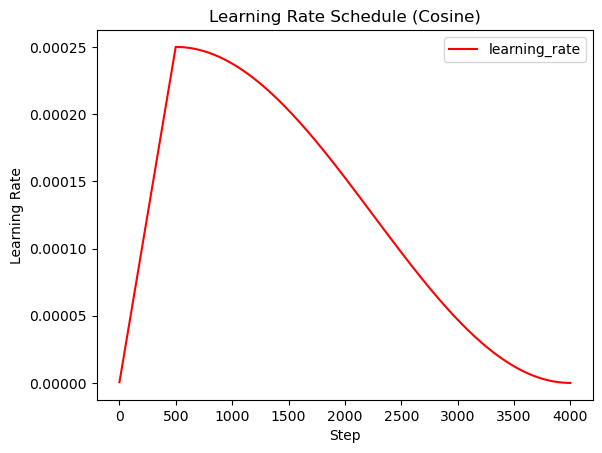

In [46]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

### 모델을 실제로 빌드해 봅시다.

In [47]:
# 모델 생성을 위한 라이브러리 설치
!pip install torchinfo

In [48]:
# 모델 생성
from torchinfo import summary

config.n_seq = 128
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)])

Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 128]                 --
│    └─SharedEmbedding: 2-1                                  [10, 128, 128]            1,024,896
│    └─PositionEmbedding: 2-2                                [10, 128, 128]            --
│    │    └─Embedding: 3-1                                   [10, 128, 128]            16,384
│    └─Embedding: 2-3                                        [10, 128, 128]            256
│    └─LayerNorm: 2-4                                        [10, 128, 128]            256
│    └─Dropout: 2-5                                          [10, 128, 128]            --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 128]       

### 본격적으로 학습을 진행합니다.
- optimizer는 Adam을 사용하고, MLM과 NSP에 대한 loss와 accuracy를 알 수 있도록 하였습니다.

In [49]:
epochs = 10
batch_size = 64

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("train_steps:", train_steps)
learning_rate_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps // 10))
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss()

train_steps: 20000


- 학습시킨 모델을 콜백 함수를 사용해 저장하고, 시각화해 봅시다.

In [50]:
%%time

work_dir = os.path.expanduser('~/work/AIFFEL_quest_eng/NLP/NLP03/project')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

# 1. pre_train_inputs = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
# 1. pre_train_labels = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

# CPU tensor ------------------------------>

# 안전한 변환 함수 정의
def to_cpu_tensor(data):
    if torch.is_tensor(data):
        # GPU에 있다면 CPU로 옮기고, 그 후 텐서 반환
        return data.detach().cpu().long()
    else:
        # 리스트나 넘파이 배열인 경우
        return torch.tensor(np.array(data)).long()

# 데이터 변환 (cpu)
pre_train_inputs = [to_cpu_tensor(x) for x in pre_train_inputs]
pre_train_labels = [to_cpu_tensor(x) for x in pre_train_labels]

# 확인용
# print(f"Inputs device: {pre_train_inputs[0].device}") # cpu여야 함

# <--------------------------------- CPU tensor

train_dataset = TensorDataset(pre_train_inputs[0], pre_train_inputs[1],
                              pre_train_labels[0], pre_train_labels[1])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

pre_train_model.to(device)

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    # Epoch 진행바 추가
    epoch_pbar = tqdm(train_dataloader,
                      desc=f'Epoch {epoch+1}/{epochs}',
                      leave=False)  # True)
    # epoch_pbar = tqdm(
    #     train_dataloader,
    #     desc=f'Epoch {epoch+1}/{epochs}',
    #     leave=True,
    #     mininterval=2.0,   # 최소 2초에 한 번만 화면 갱신
    #     miniters=50        # 최소 50 step마다 한 번만 갱신
    # )

    # for batch in train_dataloader:
    for batch_idx, batch in enumerate(epoch_pbar):
        
        # 1. enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch \
            = [t.to(device) for t in batch]  # batch 루프에서 GPU 이동
        
        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = loss_fn_mlm(logits_mlm.view(-1, logits_mlm.shape[-1]), labels_mlm_batch.view(-1))

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc = (logits_mlm.argmax(dim=-1) == labels_mlm_batch).float().mean()

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

        # 진행바에 실시간 정보 표시
        if batch_idx % 1000 == 0:  # 20,000 step이면 에폭당 20번 출력
            epoch_pbar.set_postfix({
                'Loss': f'{total_loss_batch.item():.4f}',
                'NSP': f'{loss_nsp.item():.4f}',
                'MLM': f'{loss_mlm.item():.4f}',
                'NSP_Acc': f'{nsp_acc:.4f}',
                'MLM_Acc': f'{mlm_acc:.4f}'
            })

    # 결과 저장
    history['nsp_loss'].append(total_nsp_loss / len(train_dataloader))
    history['mlm_loss'].append(total_mlm_loss / len(train_dataloader))
    history['nsp_acc'].append(total_nsp_acc / len(train_dataloader))
    history['mlm_acc'].append(total_mlm_acc / len(train_dataloader))

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}, "
          f"NSP Loss: {total_nsp_loss / len(train_dataloader)}, MLM Loss: {total_mlm_loss / len(train_dataloader)}, "
          f"NSP Accuracy: {total_nsp_acc / len(train_dataloader)}, MLM Accuracy: {total_mlm_acc / len(train_dataloader)}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"{work_dir}/bert_pre_train_epoch_{epoch+1}.pt")


Epoch 1/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 2.3436014115214348, NSP Loss: 0.6460715878307819, MLM Loss: 1.6975298229455948, NSP Accuracy: 0.59621875, MLM Accuracy: 0.86793701171875


Epoch 2/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 1.7263184460401535, NSP Loss: 0.6331702551841736, MLM Loss: 1.09314819085598, NSP Accuracy: 0.5958046875, MLM Accuracy: 0.8722999267578125


Epoch 3/10:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss: 1.6685404378771782, NSP Loss: 0.6245853246748447, MLM Loss: 1.0439551128447055, NSP Accuracy: 0.6102734375, MLM Accuracy: 0.8725614013671875


Epoch 9/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 1.658991248846054, NSP Loss: 0.6211589017212391, MLM Loss: 1.0378323478400708, NSP Accuracy: 0.620296875, MLM Accuracy: 0.8726347045898437


Epoch 10/10:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 1.6490559052228928, NSP Loss: 0.6169831465482711, MLM Loss: 1.0320727592408656, NSP Accuracy: 0.628375, MLM Accuracy: 0.8726656494140625
CPU times: user 19min 37s, sys: 4.41 s, total: 19min 42s
Wall time: 19min 40s


In [51]:
print(len(history['nsp_loss']), history['nsp_loss'])

10 [0.6460715878307819, 0.6331702551841736, 0.6302078765332699, 0.6290416383445263, 0.6284779753684998, 0.6278980784416198, 0.6267817825973034, 0.6245853246748447, 0.6211589017212391, 0.6169831465482711]


In [82]:
# # 안전한 cpu 변환 함수 정의
# def to_cpu_tensor(data):
#     if torch.is_tensor(data):
#         # GPU에 있다면 CPU로 옮기고, 그 후 텐서 반환
#         return data.detach().cpu().long()
#     else:
#         # 리스트나 넘파이 배열인 경우
#         return torch.tensor(np.array(data)).long()

# # 데이터 변환 (기존의 복잡한 4단계 변환을 대체)
# pre_train_inputs = [to_cpu_tensor(x) for x in pre_train_inputs]
# pre_train_labels = [to_cpu_tensor(x) for x in pre_train_labels]

# # 확인용
# print(f"Inputs device: {pre_train_inputs[0].device}") # cpu여야 함

Inputs device: cpu


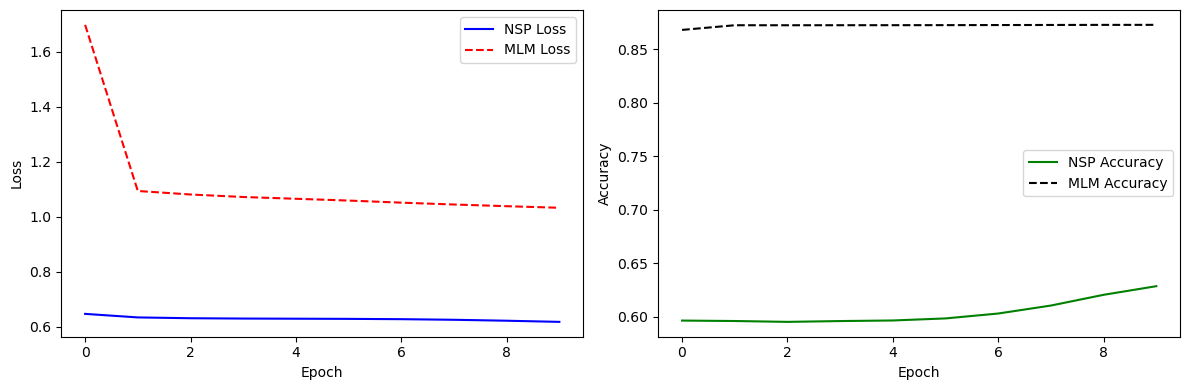

Final NSP Loss: 0.6170
Final MLM Loss: 1.0321
Final NSP Acc:  0.6284
Final MLM Acc:  0.8727


In [52]:
import matplotlib.pyplot as plt

# training result
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['nsp_loss'], 'b-', label='NSP Loss')
plt.plot(history['mlm_loss'], 'r--', label='MLM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['nsp_acc'], 'g-', label='NSP Accuracy')
plt.plot(history['mlm_acc'], 'k--', label='MLM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# plt.show()
plt.tight_layout()
plt.show()

# 마지막 에폭 결과 텍스트로도 출력
print(f"Final NSP Loss: {history['nsp_loss'][-1]:.4f}")
print(f"Final MLM Loss: {history['mlm_loss'][-1]:.4f}")
print(f"Final NSP Acc:  {history['nsp_acc'][-1]:.4f}")
print(f"Final MLM Acc:  {history['mlm_acc'][-1]:.4f}")

## 1. NSP 테스트

In [53]:
import torch
import sentencepiece as spm
import os

# 1) SentencePiece 로드
data_dir = os.path.expanduser('~/work/bert_pretrain/models')
vocab_path = os.path.join(data_dir, 'ko_8000.model')

sp = spm.SentencePieceProcessor()
sp.Load(vocab_path)   # 주의: Load (대문자 L)

# 2) 문장 쌍 인코딩
def encode_pair_for_nsp(sp, sent_a, sent_b, n_seq=128):
    tokens_a = sp.EncodeAsPieces(sent_a)
    tokens_b = sp.EncodeAsPieces(sent_b)

    tokens = ['[CLS]'] + tokens_a + ['[SEP]'] + tokens_b + ['[SEP]']
    segments = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    # 길이 자르기/패딩
    if len(tokens) > n_seq:
        tokens = tokens[:n_seq]
        segments = segments[:n_seq]
    else:
        pad_len = n_seq - len(tokens)
        tokens += ['[PAD]'] * pad_len
        segments += [0] * pad_len

    input_ids = [sp.PieceToId(t) for t in tokens]
    input_ids = torch.tensor(input_ids).unsqueeze(0)   # [1, L]
    segment_ids = torch.tensor(segments).unsqueeze(0)  # [1, L]
    return input_ids, segment_ids, tokens

# 3) NSP 테스트 + 결과 문장 표시
def test_nsp_with_sentences(model, sp, sent_a, sent_b, n_seq=128, device='cpu'):
    model.eval()
    input_ids, segment_ids, tokens = encode_pair_for_nsp(sp, sent_a, sent_b, n_seq)
    input_ids = input_ids.to(device)
    segment_ids = segment_ids.to(device)

    with torch.no_grad():
        logits_nsp, _ = model(input_ids, segment_ids)
        probs = torch.softmax(logits_nsp, dim=-1)[0].cpu().numpy()

    not_next_prob, is_next_prob = probs[0], probs[1]
    predicted = int(is_next_prob > not_next_prob)

    print("문장 A:", sent_a)
    print("문장 B:", sent_b)
    print(f"NSP probs -> not_next(0): {not_next_prob:.4f}, is_next(1): {is_next_prob:.4f}")
    print("모델 판단:", "이어지는 문장 (is_next=1)" if predicted == 1 else "이어지지 않음 (is_next=0)")

    # 이어지는 문장이라고 판단한 경우, 두 문장을 이어 붙여서 보여주기
    if predicted == 1:
        combined = sent_a + " " + sent_b
        print("\n[모델이 이어진다고 판단한 문장 연결]")
        print(combined)
    else:
        print("\n[주의] 모델은 두 문장이 이어지지 않는다고 판단했습니다.")

    return probs

# 4) 사용 예시
sent_a = "지미 카터는 미국의 제39대 대통령이다."
sent_b = "그는 조지아주 플레인스 마을에서 태어났다."

test_nsp_with_sentences(pre_train_model, sp, sent_a, sent_b, n_seq=128, device=device)


문장 A: 지미 카터는 미국의 제39대 대통령이다.
문장 B: 그는 조지아주 플레인스 마을에서 태어났다.
NSP probs -> not_next(0): 0.6797, is_next(1): 0.3203
모델 판단: 이어지지 않음 (is_next=0)

[주의] 모델은 두 문장이 이어지지 않는다고 판단했습니다.


array([0.6797174, 0.3202826], dtype=float32)

## 2. MLM 테스트용 샘플 코드

In [54]:
import torch
import sentencepiece as spm
import os

# 1) SentencePiece 로드 (이미 했다면 생략 가능)
data_dir = os.path.expanduser('~/work/bert_pretrain/models')
vocab_path = os.path.join(data_dir, 'ko_8000.model')

sp = spm.SentencePieceProcessor()
sp.Load(vocab_path)

# 2) 한 문장을 MLM용으로 인코딩 (+ 하나 토큰을 [MASK]로 교체)
def encode_single_with_mask(sp, sentence, n_seq=128):
    tokens = sp.EncodeAsPieces(sentence)
    if len(tokens) < 3:
        raise ValueError("토큰이 너무 짧습니다.")

    # 가운데 토큰 하나를 마스크
    mask_pos = len(tokens) // 2
    original_token = tokens[mask_pos]
    tokens[mask_pos] = '[MASK]'

    tokens = ['[CLS]'] + tokens + ['[SEP]']
    segments = [0] * len(tokens)

    # 패딩/자르기
    if len(tokens) > n_seq:
        tokens = tokens[:n_seq]
        segments = segments[:n_seq]
    else:
        pad_len = n_seq - len(tokens)
        tokens += ['[PAD]'] * pad_len
        segments += [0] * pad_len

    input_ids = [sp.PieceToId(t) for t in tokens]
    return (
        torch.tensor(input_ids).unsqueeze(0),   # [1, L]
        torch.tensor(segments).unsqueeze(0),    # [1, L]
        tokens,
        mask_pos + 1,       # [CLS] 때문에 인덱스 +1
        original_token
    )

# 3) MLM 테스트 함수
def test_mlm_with_sentence(model, sp, sentence, n_seq=128, device='cpu', topk=5):
    model.eval()
    input_ids, segment_ids, tokens, mask_idx, original = encode_single_with_mask(
        sp, sentence, n_seq
    )
    input_ids = input_ids.to(device)
    segment_ids = segment_ids.to(device)

    with torch.no_grad():
        _, logits_mlm = model(input_ids, segment_ids)   # [1, L, V]
        logits_mask = logits_mlm[0, mask_idx]          # [V]
        probs = torch.softmax(logits_mask, dim=-1)
        topk_ids = torch.topk(probs, k=topk).indices.cpu().numpy()

    print("원문:", sentence)
    print("토큰(앞 20개):", tokens[:20])
    print(f"[MASK] 위치 index: {mask_idx}, 정답 토큰: {original}")
    print("예측 상위 토큰:")
    for i, tid in enumerate(topk_ids):
        piece = sp.IdToPiece(int(tid))
        print(f"  {i+1}. {piece}")
    return topk_ids

# 4) 사용 예시
sentence = "지미 카터는 미국의 제39대 대통령이다."
test_mlm_with_sentence(pre_train_model, sp, sentence, n_seq=128, device=device)


원문: 지미 카터는 미국의 제39대 대통령이다.
토큰(앞 20개): ['[CLS]', '▁지', '미', '▁카', '터', '는', '▁미국의', '[MASK]', '3', '9', '대', '▁대통령', '이다', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
[MASK] 위치 index: 7, 정답 토큰: ▁제
예측 상위 토큰:
  1. .
  2. 이다
  3. 하는
  4. ▁있는
  5. ▁다른


array([3893,   24,   30,   96,  220])

In [55]:
import torch

def predict_masked_tokens_with_sentence(model, sp, sentence_with_mask, n_seq=128, device='cpu', topk=5):
    """
    예: sentence_with_mask = "지미 카터는 [MASK]의 제39대 대통령이다."
    [MASK] 위치의 상위 토큰들을 예측하고, 각 토큰을 끼운 문장도 함께 반환/출력.
    """
    model.eval()

    # 1) [MASK]가 한 개 있는지 확인
    if "[MASK]" not in sentence_with_mask:
        raise ValueError("문장 안에 [MASK] 토큰이 없습니다. 예: '... [MASK] ...' 형태로 넣어주세요.")

    # 2) SentencePiece 토크나이즈
    # [MASK]는 vocab에 등록되어 있으므로 그대로 토큰으로 취급 가능
    tokens = sp.EncodeAsPieces(sentence_with_mask)
    try:
        mask_pos = tokens.index('[MASK]')
    except ValueError:
        # 토큰 단위에서 [MASK]가 안 잡히면, 공백을 강제로 넣어 다시 시도
        sentence_proc = sentence_with_mask.replace("[MASK]", " [MASK] ")
        tokens = sp.EncodeAsPieces(sentence_proc)
        mask_pos = tokens.index('[MASK]')

    original_tokens = tokens[:]

    # 3) [CLS], [SEP] 추가
    tokens = ['[CLS]'] + tokens + ['[SEP]']
    segments = [0] * len(tokens)
    mask_idx = mask_pos + 1  # [CLS] 때문에 +1

    # 4) 패딩/자르기
    if len(tokens) > n_seq:
        tokens = tokens[:n_seq]
        segments = segments[:n_seq]
        if mask_idx >= n_seq:
            raise ValueError("시퀀스 길이(n_seq)가 너무 짧아서 [MASK] 위치가 잘렸습니다.")
    else:
        pad_len = n_seq - len(tokens)
        tokens += ['[PAD]'] * pad_len
        segments += [0] * pad_len

    input_ids = [sp.PieceToId(t) for t in tokens]
    input_ids = torch.tensor(input_ids).unsqueeze(0).to(device)
    segment_ids = torch.tensor(segments).unsqueeze(0).to(device)

    # 5) 모델 예측
    with torch.no_grad():
        _, logits_mlm = model(input_ids, segment_ids)   # [1, L, V]
        logits_mask = logits_mlm[0, mask_idx]          # [V]
        probs = torch.softmax(logits_mask, dim=-1)
        topk_ids = torch.topk(probs, k=topk).indices.cpu().numpy()

    # 6) 예측 토큰 + 복원 문장 만들기
    predicted_pieces = [sp.IdToPiece(int(tid)) for tid in topk_ids]

    print("입력 문장:", sentence_with_mask)
    print("토큰:", original_tokens)
    print(f"[MASK] 토큰 index (토큰 기준): {mask_pos}")
    print("\n예측 결과:")

    completed_sentences = []
    for i, piece in enumerate(predicted_pieces):
        # SentencePiece piece를 사람이 보기 좋은 문자열로 복원
        # ▁는 공백을 의미하므로 치환
        piece_str = piece.replace("▁", " ").strip()

        # [MASK]를 예측 토큰으로 교체한 문장
        filled_sentence = sentence_with_mask.replace("[MASK]", piece_str, 1)
        completed_sentences.append(filled_sentence)

        print(f"{i+1}. 토큰: {piece}  ->  문장: {filled_sentence}")

    return predicted_pieces, completed_sentences

# 사용 예시
masked_sentence = "지미 카터는 [MASK]의 제39대 대통령이다."
predicted_pieces, completed_sentences = predict_masked_tokens_with_sentence(
    pre_train_model, sp, masked_sentence, n_seq=128, device=device, topk=5
)


입력 문장: 지미 카터는 [MASK]의 제39대 대통령이다.
토큰: ['▁지', '미', '▁카', '터', '는', '▁', '[MASK]', '의', '▁제', '3', '9', '대', '▁대통령', '이다', '.']
[MASK] 토큰 index (토큰 기준): 6

예측 결과:
1. 토큰: .  ->  문장: 지미 카터는 .의 제39대 대통령이다.
2. 토큰: 하는  ->  문장: 지미 카터는 하는의 제39대 대통령이다.
3. 토큰: ▁크고  ->  문장: 지미 카터는 크고의 제39대 대통령이다.
4. 토큰: ▁있는  ->  문장: 지미 카터는 있는의 제39대 대통령이다.
5. 토큰: ▁작은  ->  문장: 지미 카터는 작은의 제39대 대통령이다.
